### 1. 테스트용 샘플 데이터 생성
직접 데이터를 업로드하기 전, 아래 코드를 실행하여 형식이 맞는 샘플 CSV를 생성해볼 수 있습니다.

In [3]:
import zipfile
import os

zip_path = '/content/bert_model.zip'
extract_path = '/content/'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"'{zip_path}' 압축 해제 완료.")
    # 압축 해제 후 생성된 폴더 목록 확인
    print("추출된 파일/폴더:", os.listdir(extract_path))
else:
    print(f"'{zip_path}' 파일을 찾을 수 없습니다. 파일을 먼저 업로드해주세요.")

'/content/bert_model.zip' 압축 해제 완료.
추출된 파일/폴더: ['.config', 'bert_model', 'APIReviewList_rows.csv', 'bert_model.zip', 'sample_data']


In [4]:
import pandas as pd
import os

# 1. 업로드한 파일 경로와 설정
csv_file_path = '/content/APIReviewList_rows.csv'  # 실제 업로드할 파일명
text_col = 'review_description'           # 텍스트 컬럼
label_col = 'is_ad'                       # 정답 컬럼 (0: 비광고, 1: 광고)

if os.path.exists(csv_file_path):
    # 전체 데이터를 로드합니다.
    df = pd.read_csv(csv_file_path)
    print(f"'{csv_file_path}' 파일을 성공적으로 로드했습니다. 총 {len(df)}개의 행이 있습니다.")
    display(df.head())
else:
    print(f"파일을 찾을 수 없습니다. 왼쪽 파일 메뉴에서 '{csv_file_path}' 파일을 업로드해주세요.")

'/content/APIReviewList_rows.csv' 파일을 성공적으로 로드했습니다. 총 1673개의 행이 있습니다.


,id,name,review_url,review_title,review_description,reivew_bloggername​,reivew_postdate​,created_at,is_ad,is_ad_llm_pred,is_ad_bert_pred
0,1,고양이부엌 광교점,https://blog.naver.com/ddobagireview/223860335381,수원 광교 즉석떡볶이 맛집 <b>고양이부엌 광교점</b> 리뷰,맛탕도 유명하던데 맛탕도 먹어봐야징~ 광교에서 즉석떢볶이 땡길때 즉석떡볶이 맛집 <...,리뷰 일지,20250509,2026-04-24 02:40:20.245595+00,0.0,NaN,NaN
1,2,고양이부엌 광교점,https://blog.naver.com/psr9308/223448782117,수원 광교 즉석떡볶이 맛집 '<b>고양이부엌 광교점</b>' 가성비 끝판왕...,광교 즉석떡볶이 고양이부엌에서 맛있게 드셔보시길 추천드리면서 포스팅 마치겠습니다:)...,랴니의 맛탐멋탐,20240517,2026-04-24 02:40:20.245595+00,0.0,NaN,NaN
2,3,고양이부엌 광교점,https://blog.naver.com/ye_jy/224075642600,수원 즉석떡볶이 &lt;<b>고양이부엌 광교점</b>&gt; 내돈내산 후기ㅣ광교...,"방문해봤습니다 고양이부엌은 체인점으로 동탄, 강남, 정자 등등 여러군데 있어요 ! ...",Enjoyable moment,20251115,2026-04-24 02:40:20.245595+00,0.0,NaN,NaN
3,4,고양이부엌 광교점,https://blog.naver.com/w0--0w/223730522109,수원 광교 즉석 떡볶이 맛집 <b>고양이부엌 광교점</b> 후기,동네에 있는 <b>고양이 부엌</b> 맨날 가보자했다가 못갔는데 이번 기회에 가보자...,푸파가 꿈인 미동이,20250119,2026-04-24 02:40:20.245595+00,0.0,NaN,NaN
4,5,고양이부엌 광교점,https://blog.naver.com/jii_n__/224123032479,국물 맛이 끝내주는 즉석떡볶이 맛집 [<b>고양이부엌 광교점</b>]...,안녕하세요 오늘은 광교에서 맛있게 먹고온 즉떡 맛집 <b>고양이부엌 광교점</b>을...,맛집 찾아 삼만리 (*Ü*)*.¸¸♪,20251226,2026-04-24 02:40:20.245595+00,0.0,NaN,NaN


In [5]:
!pip install -q "openvino>=2023.1.0" "transformers>=4.31.0" "optimum[openvino]" "safetensors" "scikit-learn" "pandas"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.9/371.9 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 120.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.6/805.6 kB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 92.8 MB/s eta 0:00:00


In [6]:
import os
import time
import torch
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from optimum.intel.openvino import OVModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score

# --- [설정 섹션] 압축 해제된 경로로 업데이트됨 ---
hf_model_path = "/content/bert_model/transfomer"  # .safetensors 폴더
ov_model_path = "/content/bert_model/openvino"    # .xml, .bin 폴더
# ----------------------------------------------

def get_dir_size(path):
    total_size = 0
    if os.path.exists(path):
        for dirpath, dirnames, filenames in os.walk(path):
            for f in filenames:
                fp = os.path.join(dirpath, f)
                total_size += os.path.getsize(fp)
    return total_size / (1024 * 1024)  # MB

# 1. 데이터 로드 및 전처리
df_test = pd.read_csv(csv_file_path).head(100)
texts = df_test[text_col].astype(str).tolist()
labels = df_test[label_col].tolist()

# 2. 모델 및 토크나이저 로드
print("Loading models...")
tokenizer = AutoTokenizer.from_pretrained(hf_model_path)
hf_model = AutoModelForSequenceClassification.from_pretrained(hf_model_path)
ov_model = OVModelForSequenceClassification.from_pretrained(ov_model_path, device="CPU")

# 3. 벤치마크 함수 정의
def evaluate_model(model, tokenizer, texts, labels):
    preds = []
    latencies = []

    # Warm-up
    _ = model(**tokenizer(texts[0], return_tensors="pt", truncation=True, max_length=128))

    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)

        start_time = time.perf_counter()
        with torch.no_grad():
            outputs = model(**inputs)
        end_time = time.perf_counter()

        latencies.append((end_time - start_time) * 1000) # ms

        logits = outputs.logits if not isinstance(outputs, dict) else outputs['logits']
        pred = torch.argmax(logits, dim=1).item()
        preds.append(pred)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    avg_latency = np.mean(latencies)

    return acc, f1, avg_latency

# 4. 비교 실행
print("Evaluating Hugging Face Model...")
hf_acc, hf_f1, hf_lat = evaluate_model(hf_model, tokenizer, texts, labels)

print("Evaluating OpenVINO Model...")
ov_acc, ov_f1, ov_lat = evaluate_model(ov_model, tokenizer, texts, labels)

# 5. 결과 출력
results = {
    "Metric": ["Accuracy", "F1-Score", "Latency (ms)", "Model Size (MB)"],
    "HF (Safetensors)": [f"{hf_acc:.4f}", f"{hf_f1:.4f}", f"{hf_lat:.2f}ms", f"{get_dir_size(hf_model_path):.2f}MB"],
    "OpenVINO (Quantized)": [f"{ov_acc:.4f}", f"{ov_f1:.4f}", f"{ov_lat:.2f}ms", f"{get_dir_size(ov_model_path):.2f}MB"]
}

df_res = pd.DataFrame(results)
display(df_res)

print(f"\n[결과 요약]")
print(f"- 속도 향상: {hf_lat / ov_lat:.2f}배 빨라짐")
print(f"- 정확도 변화: {ov_acc - hf_acc:.4f}")

Multiple distributions found for package optimum. Picked distribution: optimum-onnx
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading models...
Evaluating Hugging Face Model...
Evaluating OpenVINO Model...


,Metric,HF (Safetensors),OpenVINO (Quantized)
0,Accuracy,0.9600,0.9600
1,F1-Score,0.9574,0.9574
2,Latency (ms),296.79ms,269.60ms
3,Model Size (MB),416.22MB,105.68MB



[결과 요약]
- 속도 향상: 1.10배 빨라짐
- 정확도 변화: 0.0000


```markdown
### 6. 결과 저장 (CSV)
비교 결과를 CSV 파일로 저장하고 로컬로 다운로드합니다.
```

In [7]:
from google.colab import files

# 파일 저장 경로 설정
output_csv_path = '/content/evaluation_results.csv'

# 데이터프레임을 CSV로 저장 (한글 깨짐 방지를 위해 utf-8-sig 사용)
df_res.to_csv(output_csv_path, index=False, encoding='utf-8-sig')

print(f"파일이 성공적으로 저장되었습니다: {output_csv_path}")

# 파일 다운로드 (브라우저에서 바로 다운로드 팝업이 뜹니다)
files.download(output_csv_path)

파일이 성공적으로 저장되었습니다: /content/evaluation_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 7. 성능 비교 시각화
모델별 주요 지표(정확도, F1-Score, 지연 시간)를 그래프로 시각화하여 비교합니다.

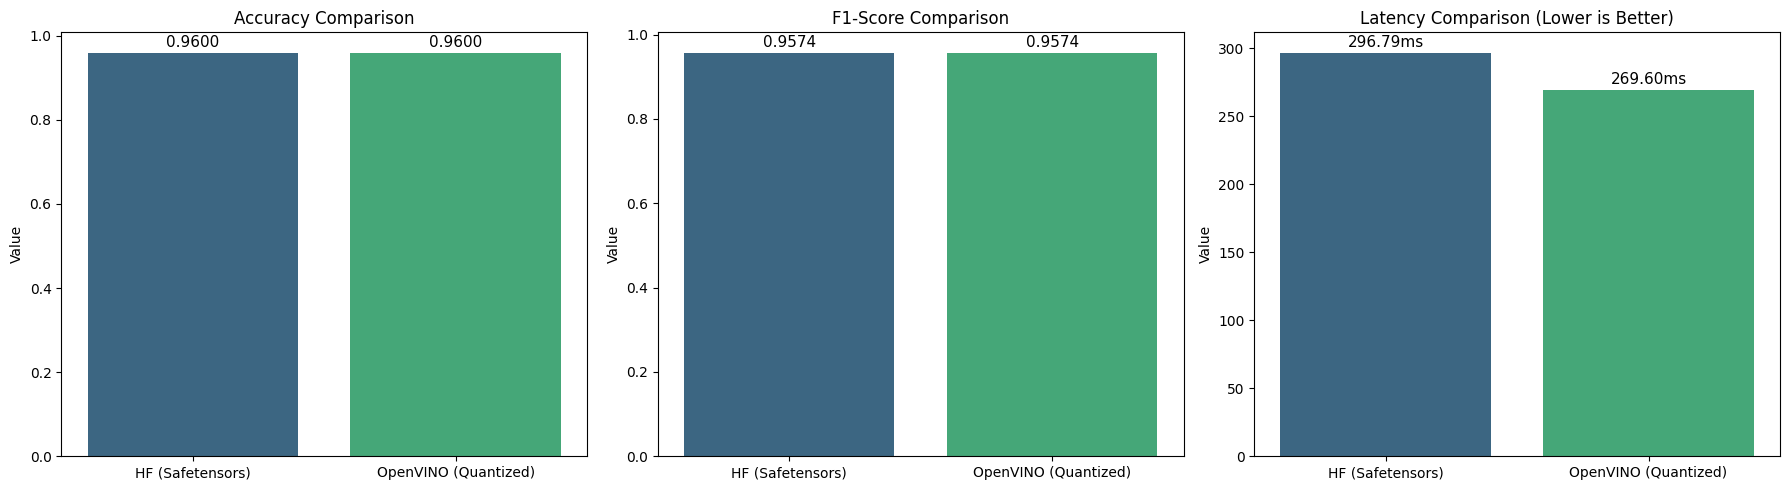

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화를 위해 데이터프레임 구조 변경
plot_df = df_res.copy()
# Latency (ms)와 Model Size (MB)에서 단위 제거 및 숫자형 변환
plot_df.iloc[2, 1:] = plot_df.iloc[2, 1:].str.replace('ms', '').astype(float)
plot_df.iloc[0, 1:] = plot_df.iloc[0, 1:].astype(float)
plot_df.iloc[1, 1:] = plot_df.iloc[1, 1:].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Accuracy', 'F1-Score', 'Latency (ms)']
titles = ['Accuracy Comparison', 'F1-Score Comparison', 'Latency Comparison (Lower is Better)']
model_names = ['HF (Safetensors)', 'OpenVINO (Quantized)']

for i, metric in enumerate(metrics):
    sns.barplot(x=plot_df.columns[1:], y=plot_df[plot_df['Metric'] == metric].iloc[0, 1:].values.astype(float), ax=axes[i], palette='viridis')
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('Value')
    axes[i].set_xlabel('') # x축 라벨을 빈 문자열로 설정하여 제거

    # 막대 위에 값 표시
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.4f}' if i < 2 else f'{p.get_height():.2f}ms',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                        textcoords='offset points')

plt.tight_layout()
plt.show()

```markdown
### 8. 그래프 이미지 저장 및 다운로드
생성된 시각화 결과(그래프)를 PNG 파일로 저장하고 다운로드합니다.
```

In [14]:
# 그래프를 이미지 파일로 저장
plot_image_path = '/content/evaluation_plot.png'
fig.savefig(plot_image_path, dpi=300, bbox_inches='tight')

print(f"그래프 이미지가 성공적으로 저장되었습니다: {plot_image_path}")

# 파일 다운로드
from google.colab import files
files.download(plot_image_path)

그래프 이미지가 성공적으로 저장되었습니다: /content/evaluation_plot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>